In [12]:
import numpy as np
import cv2
import os
import pandas as pd
from PIL import Image
import h5py
import matplotlib.pyplot as plt
from scipy import io
from time import time
import sys
from sklearn.model_selection import train_test_split
from helper_functions.data import write_h5, read_h5_numpy

print(os.getcwd())

n_scale = 7

/Users/matte/Library/CloudStorage/GoogleDrive-matteobonotto90@gmail.com/Other computers/Dell Eni/Prove/PyTorch-Lightning-template/notebooks


In [13]:
fileload = r'../data/fashion-mnist/fashion-mnist_train.csv'

data = pd.read_csv(fileload, low_memory=False).to_numpy()
X,y = data[:,1:], data[:,0].reshape(-1,1)
dims = X.shape
dims = [int(x) for x in [dims[0], np.sqrt(dims[1]), np.sqrt(dims[1])]]
X = X.reshape(dims)

X_resize = np.zeros((
    X.shape[0],
    n_scale*X.shape[1],
    n_scale*X.shape[2]))

for i in range(X.shape[0]):
    if i/10000 == i//10000:
        print('   -> Step {} of {}'.format(i,X.shape[0]))
    x = X[i,...]
    im = Image.fromarray(np.uint8(x)).convert('L').resize(
        (n_scale*x.shape[0],n_scale*x.shape[1]), Image.Resampling.LANCZOS
    )
    X_resize[i,...] = np.asarray(im)

X = X_resize.astype(dtype=np.int8)


###
X_train, X_val, y_train, y_val = train_test_split(
    X,y,
    test_size=.15,
    shuffle=True,
    random_state=42
)

dict_train = {
    'X' : X_train,
    'y' : y_train,
}

dict_val = {
    'X' : X_val,
    'y' : y_val,
}

verbose = True

write_h5(
    data = dict_train,
    filename='../data/fashion-mnist/fashion-mnist_{}x{}_train'.format(n_scale*28,n_scale*28),
    dtype=np.int8,
    verbose = verbose
    )

write_h5(
    data = dict_val,
    filename='../data/fashion-mnist/fashion-mnist_{}x{}_val'.format(n_scale*28,n_scale*28),
    dtype=np.int8,
    verbose = verbose
    )

   -> Step 0 of 60000
   -> Step 10000 of 60000
   -> Step 20000 of 60000
   -> Step 30000 of 60000
   -> Step 40000 of 60000
   -> Step 50000 of 60000
Processing key: X, dims: (51000, 196, 196), size: 1959.22MB
Processing key: y, dims: (51000, 1), size: 0.41MB
 -> DonE! Elapsed time: 11.885s, final size: 1038.61MB
Processing key: X, dims: (9000, 196, 196), size: 345.74MB
Processing key: y, dims: (9000, 1), size: 0.07MB
 -> DonE! Elapsed time: 1.810s, final size: 182.89MB


In [14]:
fileload = r'../data/fashion-mnist/fashion-mnist_test.csv'

data = pd.read_csv(fileload, low_memory=False).to_numpy()
X,y = data[:,1:], data[:,0].reshape(-1,1)
dims = X.shape
dims = [int(x) for x in [dims[0], np.sqrt(dims[1]), np.sqrt(dims[1])]]
X = X.reshape(dims)

X_resize = np.zeros((
    X.shape[0],
    n_scale*X.shape[1],
    n_scale*X.shape[2]))

for i in range(X.shape[0]):
    if i/10000 == i//10000:
        print('   -> Step {} of {}'.format(i,X.shape[0]))
    x = X[i,...]
    im = Image.fromarray(np.uint8(x)).convert('L').resize(
        (n_scale*x.shape[0],n_scale*x.shape[1]), Image.Resampling.LANCZOS
    )
    X_resize[i,...] = np.asarray(im)

X = X_resize.astype(dtype=np.int8)


###
dict_test = {
    'X' : X,
    'y' : y,
}

verbose = True

write_h5(
    data = dict_test,
    filename='../data/fashion-mnist/fashion-mnist_{}x{}_test'.format(n_scale*28,n_scale*28),
    dtype=np.int8,
    verbose = verbose
    )



   -> Step 0 of 10000
Processing key: X, dims: (10000, 196, 196), size: 384.16MB
Processing key: y, dims: (10000, 1), size: 0.00MB
 -> DonE! Elapsed time: 1.810s, final size: 202.37MB


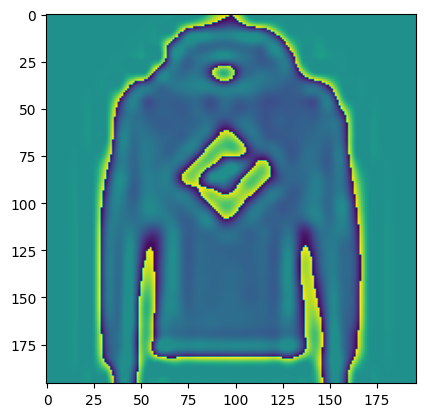

[2]


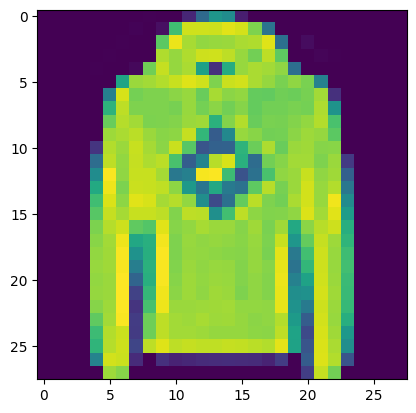

In [15]:
data_load = read_h5_numpy(
    '../data/fashion-mnist/fashion-mnist_{}x{}_test.h5'.format(n_scale*28,n_scale*28)
)

ind = 1000
# ind = 1001

plt.imshow(data_load['X'][ind,:,:])
plt.show()

paths_load = [
    r'../data/fashion-mnist/fashion-mnist_train.csv',
    r'../data/fashion-mnist/fashion-mnist_test.csv'
    ]

data = pd.read_csv(paths_load[1], low_memory=False).to_numpy()
X,y = data[:,1:], data[:,0].reshape(-1,1)
dims = X.shape
dims = [int(x) for x in [dims[0], np.sqrt(dims[1]), np.sqrt(dims[1])]]
X = X.reshape(dims)
print(y[ind])

plt.imshow(X[ind,:,:])
plt.show()